## **This notebook provides the skeletal training code for the two models mentioned in the report.**

Both curated datasets are available for download here: [Datasets](https://drive.google.com/drive/folders/1I-c3jaUw1DIroN2hwCpj22nSuEIOyFpo?usp=drive_link)

Both training approaches have been heavily modelled from the resources and tutorials covered here:


*   https://snntorch.readthedocs.io/en/latest/tutorials/tutorial_7.html

*   https://spikingjelly.readthedocs.io/zh-cn/latest/tutorials/cn/classify_dvsg.html
*   https://www.kaggle.com/code/dlarionov/create-dvs128gesture-tonic-dataset, https://github.com/AndreyUrus/IMB-DVS128gesture-snntorch


*   https://medium.com/@punyawatpck/event-based-gesture-classification-with-spiking-neural-networks-224579c9348d



### **DVSGesture Model**

In [ ]:
import numpy as np
import numpy.lib.recfunctions as rf

In [ ]:
!pip install tonic --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.2/106.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 12.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-pyth

In [ ]:
dataset_path = "/content/working/"

In [ ]:
!pip install numpy==2.0.0 --quiet
import tonic
train = tonic.datasets.DVSGesture(save_to="/content/working/", train=True)
test = tonic.datasets.DVSGesture(save_to="/content/working/", train=False)

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import HTML

def to_frames(events):
     # creates dense frames from events by binning them in different ways
    frame_transform = tonic.transforms.ToFrame(
        sensor_size=tonic.datasets.DVSGesture.sensor_size,
        #time_window=10000)
        n_time_bins=100)
        #event_count=1000)
    return frame_transform(events)

Train dataset contains 1077 samples.
There are 344788 events in the selected sample.
A single event: (67, 119, False, 32) as (x-pos, y-pos, polarity, timestamp).
(100, 2, 128, 128) 8


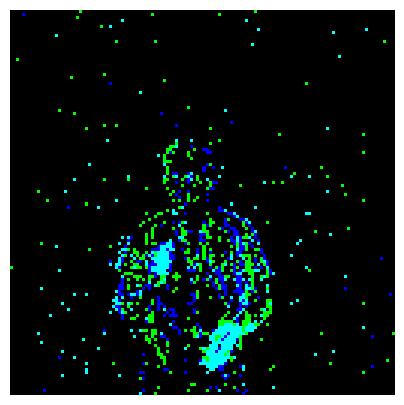

In [ ]:
events, label = train[8]
frames = to_frames(events)

print("Train dataset contains", len(train), "samples.")
print("There are", len(events), "events in the selected sample.")
print("A single event:", events[0], "as (x-pos, y-pos, polarity, timestamp).")
print (frames.shape, label)

ani = tonic.utils.plot_animation(frames) # plot one frame
HTML(ani.to_jshtml()) # animate all frames

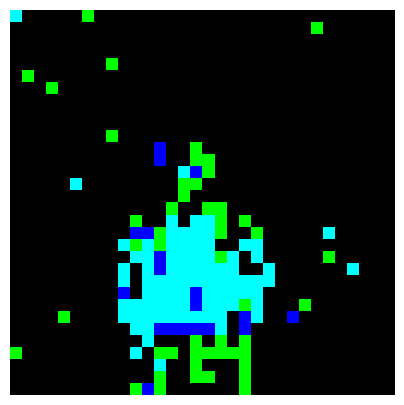

(32, 2, 32, 32) 0


In [ ]:
w,h=32,32
n_frames=32 #100
debug = False

transforms = tonic.transforms.Compose([
    tonic.transforms.Denoise(filter_time=10000), # removes outlier events with inactive surrounding pixels for 10ms
    tonic.transforms.Downsample(sensor_size=tonic.datasets.DVSGesture.sensor_size, target_size=(w,h)), # downsampling image
    tonic.transforms.ToFrame(sensor_size=(w,h,2), n_time_bins=n_frames), # n_frames frames per trail
])

train2 = tonic.datasets.DVSGesture(save_to=dataset_path, transform=transforms, train=True)
test2 = tonic.datasets.DVSGesture(save_to=dataset_path, transform=transforms, train=False)

cached_train = train2 if debug else tonic.DiskCachedDataset(train2, cache_path='/temp/dvsgesture/train')
cached_test = test2 if debug else tonic.DiskCachedDataset(test2, cache_path='/temp/dvsgesture/test')

frames, label = cached_train[1]
ani = tonic.utils.plot_animation(frames)
print(frames.shape, label)
HTML(ani.to_jshtml())

In [ ]:
!pip install snntorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 10.8 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
from snntorch import utils


In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [ ]:
grad = snn.surrogate.fast_sigmoid(slope=25) # surrogate.atan()
beta = 0.5

# 12C5-MP2-32C5-MP2-800FC11 https://snntorch.readthedocs.io/en/latest/tutorials/tutorial_7.html
net = nn.Sequential(
    nn.Conv2d(2, 12, 5), # in_channels, out_channels, kernel_size
    nn.MaxPool2d(2),
    snn.Leaky(beta=beta, spike_grad=grad, init_hidden=True),
    nn.Conv2d(12, 32, 5),
    nn.MaxPool2d(2),
    snn.Leaky(beta=beta, spike_grad=grad, init_hidden=True),
    nn.Flatten(),
    nn.Linear(800, 11), #800
    snn.Leaky(beta=beta, spike_grad=grad, init_hidden=True, output=True)
).to(device)

def forward_pass(net, data):
    spk_rec = []
    snn.utils.reset(net)  # resets hidden states for all LIF neurons in net
    for step in range(data.size(0)): # data.size(0) = number of time steps
        spk_out, mem_out = net(data[step])
        spk_rec.append(spk_out)
    return torch.stack(spk_rec)

optimizer = torch.optim.Adam(net.parameters(), lr=0.002, betas=(0.9, 0.999))
loss_fn = SF.mse_count_loss(correct_rate=0.8, incorrect_rate=0.2)

loss_hist = []
acc_hist = []
test_acc_hist = []

In [ ]:
def validate_model():
    correct, total = 0, 0
    for batch, (data, targets) in enumerate(iter(test_loader)):
        data, targets = data.to(device), targets.to(device) # [n_frames, batch, polarity, x-pos, y-pos] [batch]
        spk_rec = forward_pass(net, data)
        correct += SF.accuracy_rate(spk_rec, targets) * data.shape[0]
        total += data.shape[0]
    return correct/total

In [ ]:
num_epochs = 100
cnt = 0

train_loader = torch.utils.data.DataLoader(cached_train, batch_size=64, shuffle=True, drop_last=True,
                                           collate_fn=tonic.collation.PadTensors(batch_first=False))
test_loader = torch.utils.data.DataLoader(cached_test, batch_size=32, shuffle=True, drop_last=True,
                                          collate_fn=tonic.collation.PadTensors(batch_first=False))

for epoch in range(num_epochs):
    for batch, (data, targets) in enumerate(iter(train_loader)):
        data = data.to(device)
        targets = targets.to(device)

        net.train()
        # propagating one batch through the network and evaluating loss
        spk_rec = forward_pass(net, data)
        loss = loss_fn(spk_rec, targets)

        # Gradient calculation + weight update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Store loss history for future plotting
        loss_hist.append(loss.item())

        acc = SF.accuracy_rate(spk_rec, targets)
        acc_hist.append(acc)

        if cnt % 50 == 0:
            print(f"Epoch {epoch}, Iteration {batch} \nTrain Loss: {loss.item():.2f}")
            print(f"Train Accuracy: {acc * 100:.2f}%")
            test_acc = validate_model()
            test_acc_hist.append(test_acc)
            print(f"Test Accuracy: {test_acc * 100:.2f}%\n")

        cnt+=1

Epoch 0, Iteration 0 
Train Loss: 2.80
Train Accuracy: 12.50%
Test Accuracy: 15.62%

Epoch 3, Iteration 2 
Train Loss: 0.62
Train Accuracy: 75.00%
Test Accuracy: 56.64%

Epoch 6, Iteration 4 
Train Loss: 0.54
Train Accuracy: 78.12%
Test Accuracy: 62.50%

Epoch 9, Iteration 6 
Train Loss: 0.55
Train Accuracy: 70.31%
Test Accuracy: 61.72%

Epoch 12, Iteration 8 
Train Loss: 0.42
Train Accuracy: 84.38%
Test Accuracy: 76.17%

Epoch 15, Iteration 10 
Train Loss: 0.34
Train Accuracy: 95.31%
Test Accuracy: 80.47%

Epoch 18, Iteration 12 
Train Loss: 0.31
Train Accuracy: 93.75%
Test Accuracy: 81.25%

Epoch 21, Iteration 14 
Train Loss: 0.27
Train Accuracy: 98.44%
Test Accuracy: 83.98%

Epoch 25, Iteration 0 
Train Loss: 0.24
Train Accuracy: 100.00%
Test Accuracy: 84.77%

Epoch 28, Iteration 2 
Train Loss: 0.26
Train Accuracy: 96.88%
Test Accuracy: 85.16%

Epoch 31, Iteration 4 
Train Loss: 0.22
Train Accuracy: 98.44%
Test Accuracy: 86.72%

Epoch 34, Iteration 6 
Train Loss: 0.24
Train Accuracy

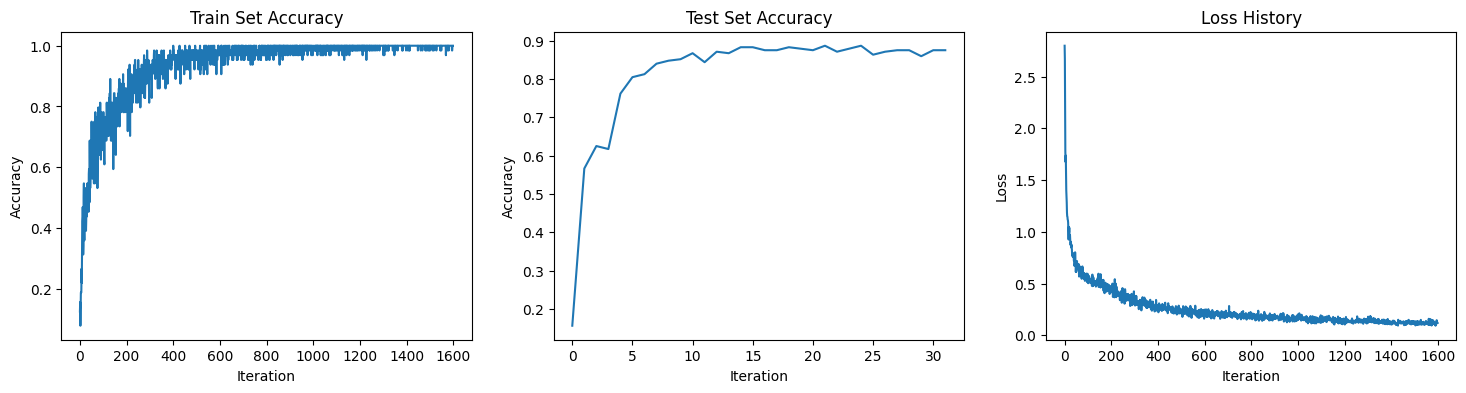

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))

# Plot Train Accuracy
axes[0].plot(acc_hist)
axes[0].set_title("Train Set Accuracy")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Accuracy")

# Plot Test Accuracy
axes[1].plot(test_acc_hist)
axes[1].set_title("Test Set Accuracy")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Accuracy")

# Plot Training Loss
axes[2].plot(loss_hist)
axes[2].set_title("Loss History")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Loss")

plt.show()

In [ ]:
validate_model(), np.max(test_acc_hist)

(np.float64(0.87890625), np.float64(0.88671875))

In [ ]:
torch.save(net.state_dict(), 'model.pth')

### **Jester Event Model**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ROOT_DRIVE = "/content/drive/MyDrive/Neuromorph-Data/Jester-Subset"

In [ ]:
import os, shutil

ROOT_LOCAL = "/content/jester_event_subset_5cls"

if not os.path.exists(ROOT_LOCAL):
    shutil.copytree(ROOT_DRIVE, ROOT_LOCAL)
    print("Copied dataset to:", ROOT_LOCAL)
else:
    print("Local dataset already exists:", ROOT_LOCAL)

ROOT = ROOT_LOCAL


Copied dataset to: /content/jester_event_subset_5cls


In [ ]:
!pip -q install pandas h5py snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 10.2 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd

ROOT = "/content/jester_event_subset_5cls"
TRAIN_DIR = "train"
VAL_DIR = "validation"

train_df = pd.read_csv(os.path.join(ROOT, "Train_small.csv"))
val_df   = pd.read_csv(os.path.join(ROOT, "Validation_small.csv"))
test_df  = pd.read_csv(os.path.join(ROOT, "Test_small.csv"))

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df.columns)


(1500, 7) (150, 7) (150, 7)
Index(['video_id', 'label', 'frames', 'label_id', 'shape', 'format', 'y'], dtype='object')


In [ ]:
def filter_missing_events(df, split_dir):
    keep = []
    missing = 0
    for _, r in df.iterrows():
        vid = str(int(r["video_id"]))
        h5 = os.path.join(ROOT, split_dir, vid, "events.h5")
        if os.path.exists(h5):
            keep.append(r)
        else:
            missing += 1
    return pd.DataFrame(keep).reset_index(drop=True), missing

train_df2, mtr = filter_missing_events(train_df, TRAIN_DIR)
val_df2,   mva = filter_missing_events(val_df,   VAL_DIR)
test_df2,  mts = filter_missing_events(test_df,  VAL_DIR)

print("Missing events.h5 (train/val/test):", mtr, mva, mts)
print("Kept (train/val/test):", len(train_df2), len(val_df2), len(test_df2))


Missing events.h5 (train/val/test): 0 0 0
Kept (train/val/test): 1500 150 150


In [ ]:
import numpy as np
import h5py
import torch
from torch.utils.data import Dataset, DataLoader

T = 32
H = W = 48

def load_events_h5(path):
    with h5py.File(path, "r") as f:
        ev = f["events"][:]  # [N,4] uint32: [t,x,y,p]
    t = ev[:,0].astype(np.int64)
    x = ev[:,1].astype(np.int64)
    y = ev[:,2].astype(np.int64)
    p = ev[:,3].astype(np.int64)  # 0/1
    return t, x, y, p

def events_to_frames(t, x, y, p, T=16, H=64, W=64):
    # map dvs128 coords 0..127 -> 0..W-1 / 0..H-1
    x = (x * (W - 1) // 127).astype(np.int64)
    y = (y * (H - 1) // 127).astype(np.int64)

    t0, t1 = int(t.min()), int(t.max())
    if t1 <= t0:
        t1 = t0 + 1

    edges = np.linspace(t0, t1, T + 1, dtype=np.float64)
    bin_idx = np.searchsorted(edges, t, side="right") - 1
    bin_idx = np.clip(bin_idx, 0, T - 1).astype(np.int64)

    frames = np.zeros((T, 2, H * W), dtype=np.float32)
    flat = (y * W + x).astype(np.int64)

    for pol in (0, 1):
        m = (p == pol)
        if np.any(m):
            bi = bin_idx[m]
            fi = flat[m]
            np.add.at(frames, (bi, np.full_like(bi, pol), fi), 1.0)

    frames = frames.reshape(T, 2, H, W)

    # stabilize + normalize
    frames = np.log1p(frames)
    # frames = frames / (frames.max() + 1e-6)
    mx = frames.reshape(T, -1).max(axis=1, keepdims=True) + 1e-6
    frames = (frames.reshape(T, -1) / mx).reshape(T, 2, H, W)
    return frames.astype(np.float32)

class JesterEventFrames(Dataset):
    def __init__(self, df, split_dir, root, T=16, H=64, W=64, train_mode=False, crop_s=2.0):
        self.df = df.reset_index(drop=True)
        self.split_dir = split_dir
        self.root = root
        self.T, self.H, self.W = T, H, W
        self.train_mode = train_mode
        self.crop_us = int(crop_s * 1e6) if (train_mode and crop_s is not None) else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        vid = str(int(r["video_id"]))
        y = int(r["y"])
        path = os.path.join(self.root, self.split_dir, vid, "events.h5")

        t, x, yy, p = load_events_h5(path)

        # random temporal crop for training
        if self.crop_us is not None:
            t0, t1 = int(t.min()), int(t.max())
            dur = max(t1 - t0, 1)
            if dur > self.crop_us:
                start = np.random.randint(t0, t1 - self.crop_us)
                m = (t >= start) & (t < start + self.crop_us)
                t, x, yy, p = t[m], x[m], yy[m], p[m]

        frames = events_to_frames(t, x, yy, p, T=self.T, H=self.H, W=self.W)
        return torch.tensor(frames), torch.tensor(y)


In [ ]:
train_ds = JesterEventFrames(train_df2, TRAIN_DIR, ROOT, T=T, H=H, W=W, train_mode=True,  crop_s=3.0)
val_ds   = JesterEventFrames(val_df2,   VAL_DIR,   ROOT, T=T, H=H, W=W, train_mode=False)
test_ds  = JesterEventFrames(test_df2,  VAL_DIR,   ROOT, T=T, H=H, W=W, train_mode=False)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Num batches:", len(train_loader), len(val_loader), len(test_loader))


Num batches: 47 5 5


In [ ]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate
from snntorch import utils

class GestureSNN(nn.Module):
    def __init__(self, num_classes, beta=0.9, H=48, W=48, thresh=1.0):
        super().__init__()
        grad = surrogate.fast_sigmoid(slope=25)

        self.conv1 = nn.Conv2d(2, 32, 5, padding=2)
        self.pool1 = nn.MaxPool2d(2)
        self.lif1  = snn.Leaky(beta=beta, spike_grad=grad, init_hidden=True, threshold=thresh)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
        self.lif2  = snn.Leaky(beta=beta, spike_grad=grad, init_hidden=True, threshold=thresh)

        with torch.no_grad():
            dummy = torch.zeros(1, 2, H, W)
            z = self.pool1(self.conv1(dummy))
            z = self.lif1(z)
            z = self.pool2(self.conv2(z))
            z = self.lif2(z)
            flat_dim = z.flatten(1).shape[1]

        self.fc   = nn.Linear(flat_dim, num_classes)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=grad, init_hidden=True, output=True, threshold=thresh)

    def forward(self, x_TBCHW):
        # x_TBCHW: [T,B,2,H,W]
        spk_rec, mem_rec = [], []
        utils.reset(self)

        for t in range(x_TBCHW.size(0)):
            x = x_TBCHW[t]                           # [B,2,H,W]
            z = self.pool1(self.conv1(x))
            z = self.lif1(z)                      # spikes forward
            z = self.pool2(self.conv2(z))
            z = self.lif2(z)                      # spikes forward
            z = z.flatten(1)
            z = self.fc(z)
            spk, mem = self.lif3(z)                  # [B,K], [B,K]
            spk_rec.append(spk)
            mem_rec.append(mem)

        return torch.stack(spk_rec), torch.stack(mem_rec)  # both [T,B,K]


In [ ]:
@torch.no_grad()
def eval_acc_both(loader):
    net.eval()
    correct_spk = 0
    correct_mem = 0
    total = 0
    for frames, y in loader:
        frames = frames.permute(1,0,2,3,4).to(device)  # [T,B,2,H,W]
        y = y.to(device)

        spk, mem = net(frames)            # [T,B,K]
        pred_spk = spk.sum(0).argmax(1)   # [B]
        pred_mem = mem.sum(0).argmax(1)   # [B]

        correct_spk += (pred_spk == y).sum().item()
        correct_mem += (pred_mem == y).sum().item()
        total += y.numel()

    return correct_spk/total, correct_mem/total


In [ ]:
import torch.nn as nn
ce = nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
K = int(train_df2["y"].nunique())

net = GestureSNN(num_classes=K, beta=0.9, H=H, W=W, thresh=1.0).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)

best_val = -1.0
best_path = "/content/best_snn_memlogits.pt"

EPOCHS = 40

for epoch in range(EPOCHS):
    net.train()
    for frames, y in train_loader:
        frames = frames.permute(1,0,2,3,4).to(device)
        y = y.to(device)

        spk, mem = net(frames)
        logits = mem.sum(dim=0)     # membrane logits
        loss = ce(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    tr_spk, tr_mem = eval_acc_both(train_loader)
    va_spk, va_mem = eval_acc_both(val_loader)

    # checkpoint on membrane-val (since that's what we train for)
    if va_mem > best_val:
        best_val = va_mem
        torch.save(net.state_dict(), best_path)

    print(f"epoch {epoch:02d} | train spk {tr_spk:.3f} mem {tr_mem:.3f} | "
          f"val spk {va_spk:.3f} mem {va_mem:.3f} | best(mem) {best_val:.3f}")

net.load_state_dict(torch.load(best_path, map_location=device))
te_spk, te_mem = eval_acc_both(test_loader)
print("TEST spk:", te_spk, "TEST mem:", te_mem)
print("Saved:", best_path)



epoch 00 | train spk 0.200 mem 0.311 | val spk 0.200 mem 0.313 | best(mem) 0.313
epoch 01 | train spk 0.200 mem 0.379 | val spk 0.200 mem 0.373 | best(mem) 0.373
epoch 02 | train spk 0.200 mem 0.358 | val spk 0.200 mem 0.260 | best(mem) 0.373
epoch 03 | train spk 0.200 mem 0.449 | val spk 0.200 mem 0.367 | best(mem) 0.373
epoch 04 | train spk 0.200 mem 0.485 | val spk 0.200 mem 0.380 | best(mem) 0.380
epoch 05 | train spk 0.200 mem 0.461 | val spk 0.200 mem 0.367 | best(mem) 0.380
epoch 06 | train spk 0.200 mem 0.545 | val spk 0.200 mem 0.420 | best(mem) 0.420
epoch 07 | train spk 0.200 mem 0.613 | val spk 0.200 mem 0.393 | best(mem) 0.420
epoch 08 | train spk 0.200 mem 0.603 | val spk 0.200 mem 0.407 | best(mem) 0.420
epoch 09 | train spk 0.200 mem 0.575 | val spk 0.200 mem 0.433 | best(mem) 0.433
epoch 10 | train spk 0.200 mem 0.684 | val spk 0.200 mem 0.387 | best(mem) 0.433
epoch 11 | train spk 0.200 mem 0.709 | val spk 0.200 mem 0.413 | best(mem) 0.433
epoch 12 | train spk 0.200 m

In [ ]:
import numpy as np

# If your CSV already includes the original label string, print that too
frames, y = test_ds[8]
true_y = int(y)

net.eval()
with torch.no_grad():
    x = frames.unsqueeze(0).permute(1,0,2,3,4).to(device)  # [T,1,2,H,W]
    spk, mem = net(x)                         # [T,1,K]
    counts = spk.sum(dim=0).squeeze(0).cpu().numpy()  # [K]
    pred_y = int(np.argmax(counts))

    pred_spk = spk.sum(0).argmax(1)
    pred_mem = mem.sum(0).argmax(1)
    print(pred_spk, pred_mem)

print("True y:", true_y, "Pred y:", pred_y)
print("Spike counts:", counts)


ValueError: too many values to unpack (expected 2)

In [ ]:
import numpy as np
import torch

# If you already have these:
# label_to_idx = {"Thumb Up":0, ...}
# idx_to_label = {0:"Thumb Up", ...}
# K = number of classes
idx_to_label = {v:k for k,v in label_to_idx.items()}
K = len(idx_to_label)

@torch.no_grad()
def confusion_matrix_both(loader):
    net.eval()
    cm_mem = np.zeros((K, K), dtype=np.int64)
    cm_spk = np.zeros((K, K), dtype=np.int64)

    for frames, y in loader:
        frames = frames.permute(1,0,2,3,4).to(device)  # [T,B,2,H,W]
        y = y.to(device)

        spk, mem = net(frames)          # [T,B,K], [T,B,K]
        pred_mem = mem.sum(0).argmax(1) # [B]
        pred_spk = spk.sum(0).argmax(1) # [B]

        yt = y.cpu().numpy()
        pm = pred_mem.cpu().numpy()
        ps = pred_spk.cpu().numpy()

        for a, b in zip(yt, pm):
            cm_mem[int(a), int(b)] += 1
        for a, b in zip(yt, ps):
            cm_spk[int(a), int(b)] += 1

    return cm_mem, cm_spk

def print_cm(cm, title="Confusion matrix"):
    print(title, "(rows=true, cols=pred):\n", cm)
    per_class = cm.diagonal() / (cm.sum(axis=1) + 1e-9)
    for i in range(K):
        print(f"{i} {idx_to_label[i]:25s} acc={per_class[i]:.3f}  (n={cm.sum(axis=1)[i]})")

cm_mem, cm_spk = confusion_matrix_both(test_loader)

print_cm(cm_mem, title="MEM readout confusion matrix")
print()
print_cm(cm_spk, title="SPK readout confusion matrix")


MEM readout confusion matrix (rows=true, cols=pred):
 [[12  1  8  4  5]
 [ 2 21  1  4  2]
 [ 6  6 11  2  5]
 [ 3  3  6  9  9]
 [ 2  4  7  5 12]]
0 Thumb Up                  acc=0.400  (n=30)
1 Shaking Hand              acc=0.700  (n=30)
2 Swiping Up                acc=0.367  (n=30)
3 Zooming In With Full Hand acc=0.300  (n=30)
4 Turning Hand Clockwise    acc=0.400  (n=30)

SPK readout confusion matrix (rows=true, cols=pred):
 [[30  0  0  0  0]
 [28  2  0  0  0]
 [30  0  0  0  0]
 [30  0  0  0  0]
 [30  0  0  0  0]]
0 Thumb Up                  acc=1.000  (n=30)
1 Shaking Hand              acc=0.067  (n=30)
2 Swiping Up                acc=0.000  (n=30)
3 Zooming In With Full Hand acc=0.000  (n=30)
4 Turning Hand Clockwise    acc=0.000  (n=30)


In [ ]:
import numpy as np
import torch

def topk_dict(arr, k=3):
    idx = np.argsort(arr)[::-1][:k]
    return {idx_to_label[int(i)]: float(arr[int(i)]) for i in idx}

@torch.no_grad()
def show_examples_memspk(test_ds, test_df2, n=10, start=0):
    net.eval()

    for i in range(start, min(start+n, len(test_ds))):
        frames, y = test_ds[i]
        true_y = int(y.item())
        vid = None
        if test_df2 is not None and "video_id" in test_df2.columns:
            vid = int(test_df2.iloc[i]["video_id"])

        x = frames.unsqueeze(0).permute(1,0,2,3,4).to(device)  # [T,1,2,H,W]
        spk, mem = net(x)

        spk_counts = spk.sum(0).squeeze(0).cpu().numpy()   # [K]
        mem_logits = mem.sum(0).squeeze(0).cpu().numpy()   # [K]

        pred_spk = int(np.argmax(spk_counts))
        pred_mem = int(np.argmax(mem_logits))

        # A simple confidence proxy: margin between top-1 and top-2
        mem_sorted = np.sort(mem_logits)[::-1]
        mem_margin = float(mem_sorted[0] - mem_sorted[1]) if len(mem_sorted) > 1 else float("nan")

        print("-"*70)
        if vid is not None:
            print(f"i={i} video_id={vid}")
        else:
            print(f"i={i}")

        print(f"true: {idx_to_label[true_y]}")
        print(f"pred_mem: {idx_to_label[pred_mem]}   (margin={mem_margin:.4f})")
        print(f"pred_spk: {idx_to_label[pred_spk]}")
        print("top3 mem logits:", topk_dict(mem_logits, k=3))
        print("spike counts:", {idx_to_label[j]: float(spk_counts[j]) for j in range(K)})

# Example usage:
show_examples_memspk(test_ds, test_df2, n=10, start=0)


----------------------------------------------------------------------
i=0 video_id=35440
true: Shaking Hand
pred_mem: Thumb Up   (margin=8.8466)
pred_spk: Thumb Up
top3 mem logits: {'Thumb Up': 1.8658428192138672, 'Swiping Up': -6.980775356292725, 'Shaking Hand': -8.514331817626953}
spike counts: {'Thumb Up': 0.0, 'Shaking Hand': 0.0, 'Swiping Up': 0.0, 'Zooming In With Full Hand': 0.0, 'Turning Hand Clockwise': 0.0}
----------------------------------------------------------------------
i=1 video_id=13054
true: Thumb Up
pred_mem: Turning Hand Clockwise   (margin=0.0775)
pred_spk: Thumb Up
top3 mem logits: {'Turning Hand Clockwise': -3.441439151763916, 'Zooming In With Full Hand': -3.51896071434021, 'Shaking Hand': -3.9266433715820312}
spike counts: {'Thumb Up': 0.0, 'Shaking Hand': 0.0, 'Swiping Up': 0.0, 'Zooming In With Full Hand': 0.0, 'Turning Hand Clockwise': 0.0}
----------------------------------------------------------------------
i=2 video_id=72811
true: Shaking Hand
pred_mem